In [1]:
!git clone https://github.com/KrunoslavLesic/Zavrsni-rad-QLoRA-fine-tuning.git

fatal: destination path 'Zavrsni-rad-QLoRA-fine-tuning' already exists and is not an empty directory.


In [2]:
%cd /content/Zavrsni-rad-QLoRA-fine-tuning/notebooks

/content/Zavrsni-rad-QLoRA-fine-tuning/notebooks


# Dotreniravanje modela Qwen3-1.7B primjenom QLoRA metode

Ova bilježnica sadrži cjelokupan postupak proveden u praktičnom dijelu završnog rada, od pripreme skupa podataka do dotreniravanja i evaluacije modela.

## Tijek izvođenja

1. Učitavanje i priprema skupa podataka
2. Konfiguracija i priprema modela za QLoRA dotreniravanje
3. Dotreniravanje modela Qwen3-1.7B
4. Spremanje dotreniranog modela
5. Evaluacija dotreniranog modela
6. Evaluacija baznog modela


In [3]:
pip install -r requirements.txt

In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
     data_files={
        "ISA_240": "../dataset/ISA-240.json",
        "ISA_315": "../dataset/ISA-315.json",
        "ISA_500_draft": "../dataset/ISA-500.json",
        "complex_scenarios": "../dataset/slozeni_scenariji.json"
    }
)

In [5]:
from datasets import concatenate_datasets
full_datasets = concatenate_datasets([dataset["ISA_240"], dataset["ISA_315"], dataset["ISA_500_draft"], dataset["complex_scenarios"]])

In [6]:
print(f"Ukupno primjera: {len(full_datasets)}")

split = full_datasets.train_test_split(
    test_size=0.2,
    shuffle=True,
    seed=42
)
test_valid = split["test"].train_test_split(
    test_size=0.5,
    shuffle=True,
    seed=42
)

train_dataset = split["train"]
validation_dataset = test_valid["train"]
test_dataset = test_valid["test"]

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(validation_dataset)}")
print(f"Test: {len(test_dataset)}")

Ukupno primjera: 2546
Train: 2036
Validation: 255
Test: 255


In [7]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_name = "Qwen/Qwen3-1.7B"


quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)


model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
)


tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Model loaded: {model_name}")
print(f"Model memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen3-1.7B
Model memory footprint: 1.33 GB


In [8]:
def formatting_func(example):

    messages = [
        {
            "role": "user",
            "content": example["instruction"]
            + ("\n\n" + example["input"] if example["input"].strip() else "")
        },
        {
            "role": "assistant",
            "content": example["output"]
        }
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

In [9]:


model = prepare_model_for_kbit_training(model)


lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)


model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861


In [10]:
formatted_dataset = train_dataset.map(
    lambda x: {"text": formatting_func(x)}
)

In [11]:
import transformers
from trl import SFTTrainer
from transformers import EarlyStoppingCallback


from trl import SFTConfig

training_args = SFTConfig(
    output_dir = "../model",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    learning_rate=2e-4,
    num_train_epochs=3,

    weight_decay=0.01,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=20,

    max_length=1024,
    packing=False,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",
)


trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    formatting_func=formatting_func,
    processing_class=tokenizer
)

In [12]:
import time
import torch

print("Starting QLoRA fine-tuning...")

torch.cuda.reset_peak_memory_stats()
start_time = time.time()

train_result = trainer.train()

end_time = time.time()

training_time = end_time - start_time
peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)

print("Training finished.")
print(f"Vrijeme dotreniranja: {training_time / 60:.2f} minuta")
print(f"Najveća potrošnja GPU memorije: {peak_memory:.2f} GB")
print(f"Broj trenirajućih parametara: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting QLoRA fine-tuning...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.426058,1.381856,1.315947,656414.000000,0.632677
2,1.199552,1.326027,1.202185,1312828.000000,0.644369
3,1.055609,1.341334,1.094228,1969242.000000,0.642852


Training finished.
Vrijeme dotreniranja: 15.17 minuta
Najveća potrošnja GPU memorije: 5.66 GB
Broj trenirajućih parametara: 34,865,152


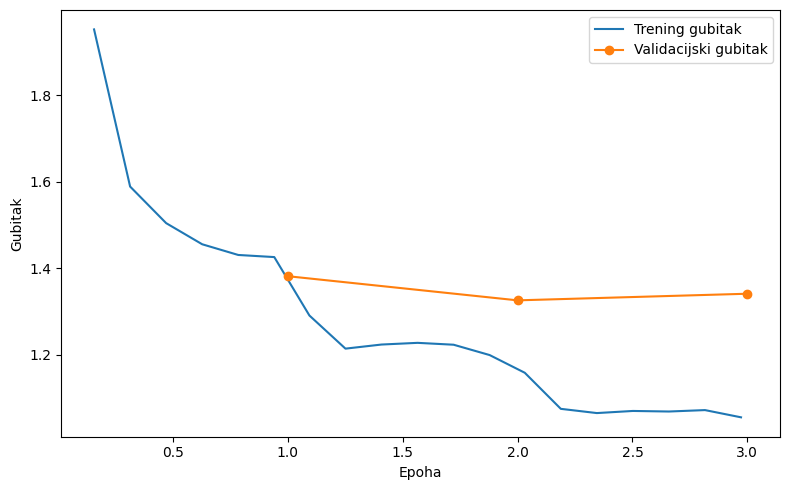

In [14]:
train_loss = history.dropna(subset=["loss"])
eval_loss = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 5))

plt.plot(
    train_loss["epoch"],
    train_loss["loss"],
    label="Trening gubitak"
)

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="o",
    label="Validacijski gubitak"
)

plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import os

save_path = "../model/final_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model spremljen u:", save_path)
print(os.listdir(save_path))

Model spremljen u: ../model/final_model
['training_args.bin', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'chat_template.jinja']


In [16]:
!pip uninstall -y torchao

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained(
    "../model/final_model"
)

model = PeftModel.from_pretrained(
    base_model,
    "../model/final_model"
)

model.eval()

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [17]:
import os
import torch
import pandas as pd
from tqdm import tqdm


model.eval()

try:
    model = torch.compile(model)
except:
    pass


test_data = test_dataset


def generate_answer(model, tokenizer, prompt, max_new_tokens=1024):

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    answer = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    del inputs
    del outputs

    return answer.strip()


results = []

csv_path = "../results/fine_tuned_results.csv"

os.makedirs(os.path.dirname(csv_path), exist_ok=True)

print()
print("=" * 60)
print(f"Pokrećem evaluaciju na {len(test_data)} primjera")
print("=" * 60)


for idx in tqdm(range(len(test_data)), desc="Evaluating"):

    example = test_data[idx]

    try:

        instruction = example["instruction"]
        input_text = example["input"]
        expected_output = example["output"]

        prompt = instruction

        if input_text.strip():
            prompt += "\n\n" + input_text

        ft_answer = generate_answer(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=1024
        )

        results.append({

            "id": idx,
            "instruction": instruction,
            "input": input_text,
            "question": prompt,
            "expected_output": expected_output,
            "finetuned_model_output": ft_answer

        })

    except Exception as e:

        print(f"\nGreška na primjeru {idx}")
        print(e)

        results.append({

            "id": idx,
            "instruction": "",
            "input": "",
            "question": "",
            "expected_output": "",
            "finetuned_model_output": f"ERROR: {e}"

        })

    # Spremanje nakon svakog primjera
    pd.DataFrame(results).to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Spremljeno {len(results)}/{len(test_data)}")


df_results = pd.DataFrame(results)

print()
print("=" * 60)
print("EVALUACIJA ZAVRŠENA")
print("=" * 60)
print(f"Rezultati spremljeni u:\n{csv_path}")
print(f"Ukupno primjera: {len(results)}")


Pokrećem evaluaciju na 255 primjera


Evaluating:   0%|          | 1/255 [00:15<1:04:29, 15.23s/it]

Spremljeno 1/255


Evaluating:   1%|          | 2/255 [00:34<1:13:15, 17.37s/it]

Spremljeno 2/255


...

Spremljeno 253/255


Evaluating: 100%|█████████▉| 254/255 [1:20:52<00:14, 14.57s/it]

Spremljeno 254/255


Evaluating: 100%|██████████| 255/255 [1:21:56<00:00, 19.28s/it]

Spremljeno 255/255

EVALUACIJA ZAVRŠENA
Rezultati spremljeni u:
../results/fine_tuned_results.csv
Ukupno primjera: 255


In [18]:
base_model_name = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [19]:
import os
import torch
import pandas as pd
from tqdm import tqdm


model.eval()

try:
    model = torch.compile(model)
except:
    pass


test_data = test_dataset


def generate_answer(model, tokenizer, prompt, max_new_tokens=1024):

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    answer = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    del inputs
    del outputs

    return answer.strip()


results = []

csv_path = "../results/base_model_results.csv"

os.makedirs(os.path.dirname(csv_path), exist_ok=True)

print()
print("=" * 60)
print(f"Pokrećem evaluaciju na {len(test_data)} primjera")
print("=" * 60)


for idx in tqdm(range(len(test_data)), desc="Evaluating"):

    example = test_data[idx]

    try:

        instruction = example["instruction"]
        input_text = example["input"]
        expected_output = example["output"]

        prompt = instruction

        if input_text.strip():
            prompt += "\n\n" + input_text

        base_answer = generate_answer(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=1024
        )

        results.append({

            "id": idx,
            "instruction": instruction,
            "input": input_text,
            "question": prompt,
            "expected_output": expected_output,
            "base_model_output": base_answer

        })

    except Exception as e:

        print(f"\nGreška na primjeru {idx}")
        print(e)

        results.append({

            "id": idx,
            "instruction": "",
            "input": "",
            "question": "",
            "expected_output": "",
            "base_model_output": f"ERROR: {e}"

        })

    # Spremanje nakon svakog primjera
    pd.DataFrame(results).to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Spremljeno {len(results)}/{len(test_data)}")


df_results = pd.DataFrame(results)

print()
print("=" * 60)
print("EVALUACIJA ZAVRŠENA")
print("=" * 60)
print(f"Rezultati spremljeni u:\n{csv_path}")
print(f"Ukupno primjera: {len(results)}")


Pokrećem evaluaciju na 255 primjera


Evaluating:   0%|          | 1/255 [00:10<43:46, 10.34s/it]

Spremljeno 1/255


Evaluating:   1%|          | 2/255 [00:30<1:07:41, 16.05s/it]

Spremljeno 2/255


...

Spremljeno 253/255


Evaluating: 100%|█████████▉| 254/255 [1:55:39<00:26, 26.49s/it]

Spremljeno 254/255


Evaluating: 100%|██████████| 255/255 [1:56:19<00:00, 27.37s/it]

Spremljeno 255/255

EVALUACIJA ZAVRŠENA
Rezultati spremljeni u:
../results/base_model_results.csv
Ukupno primjera: 255
